# Anexos de simulaciones --- `entrega/tesis/main.tex`

Genera 3 figuras PDF para el anexo de la tesis. Cada figura compara, sobre una
seleccion curada de DGPs Monte Carlo, el pronostico de **Chronos-2** contra el
**mejor metodo clasico** del bloque. Estilo: `plot_forecast_fan` (historia +
realizado + media de cada modelo + bandas 80/95 %).

**Outputs en `entrega/tesis/output/`**:
- `anexo_simulaciones_univariadas.pdf` --- 8 DGPs (grid 4x2): 1 por bloque A-G + extra A.4
- `anexo_simulaciones_multivariadas.pdf` --- 6 DGPs bivariados (3x2), cada uno con 2 sub-paneles (una variable por panel)
- `anexo_simulaciones_covariadas.pdf` --- 6 DGPs (3x2), cada uno con target + exogena apilados

Requisitos: el modelo `amazon/chronos-2` debe estar cacheado en `~/.cache/huggingface`.
Tiempo estimado: ~15-30 min en CPU local.

## 0 · Setup

In [1]:
import os
# Modo offline para HuggingFace: usa solo el modelo Chronos-2 cacheado localmente
# (~/.cache/huggingface). Necesario porque la validacion HEAD vs huggingface.co
# falla con SSLCertVerificationError en este entorno.
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

import sys, warnings, pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from mectesis.empirical.describe import plot_forecast_fan
from mectesis.dgp import (
    ARpDGP, MAqDGP, ARMApqDGP, ARMApqWithTrendDGP,
    RandomWalk, AR1GARCH, DampedTrendDGP, SeasonalDGP,
    VARDGP, VECMBivariateDGP, VARGARCHDiagonalDGP,
    ARIMAX_DGP, ARIMAX_GARCH_DGP, SARIMAX_SEASONAL_DGP, ADL_ECM_DGP,
)
from mectesis.models import (
    ChronosModel, ChronosMultivariateModel, ChronosCovariateModel,
    VARModel, VECMModel,
)
from mectesis.empirical.autoselect import (
    AutoARIMAModel, AutoETSModel, AutoSARIMAXModel,
)

SEED = 42
T_TRAIN = 200          # observaciones de entrenamiento
HORIZON = 24           # h maximo del pronostico
HISTORY_TAIL = 36      # cola historica visible en el fan-plot
TOTAL = T_TRAIN + HORIZON

ROOT = pathlib.Path.cwd().parent
OUTPUT_DIR = ROOT / "entrega" / "tesis" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

# rcParams tipograficos (serif tipo Computer Modern, coincide con main.tex)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Paleta consistente con tesis_visuales.ipynb
CHRONOS_COLOR = "#9672B6"
CLASSIC_COLOR = "#4C72B0"
MODEL_COLORS = {
    "Chronos-2":    CHRONOS_COLOR,
    "AutoARIMA":    CLASSIC_COLOR,
    "AutoETS":      CLASSIC_COLOR,
    "AutoSARIMAX":  CLASSIC_COLOR,
    "VAR(1)":       CLASSIC_COLOR,
    "VAR(2)":       CLASSIC_COLOR,
    "VECM(r=1)":    CLASSIC_COLOR,
}

print("Cargando Chronos-2 desde cache local...")
chronos = ChronosModel(device="cpu")
print("Listo.")

OUTPUT_DIR: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\entrega\tesis\output
Cargando Chronos-2 desde cache local...
Listo.


## 1 · Helpers

In [2]:
def to_series(arr, name="y"):
    return pd.Series(arr, index=pd.RangeIndex(len(arr)), name=name)


def to_frame(arr, prefix="y"):
    return pd.DataFrame(
        arr,
        index=pd.RangeIndex(arr.shape[0]),
        columns=[f"{prefix}{j+1}" for j in range(arr.shape[1])],
    )


def fan_dict_uni(model, y_train, horizon):
    """Fit + forecast + intervals para un modelo univariado. Devuelve dict para plot_forecast_fan."""
    model.fit(np.asarray(y_train, dtype=float))
    mean = np.asarray(model.forecast(horizon), dtype=float)
    lo80, hi80 = model.forecast_intervals(horizon, level=0.80)
    lo95, hi95 = model.forecast_intervals(horizon, level=0.95)
    return {
        "mean": mean,
        "lo80": np.asarray(lo80, dtype=float),
        "hi80": np.asarray(hi80, dtype=float),
        "lo95": np.asarray(lo95, dtype=float),
        "hi95": np.asarray(hi95, dtype=float),
    }


def fan_dict_multi(model, Y_train, horizon):
    """Fit + forecast + intervals para un modelo multivariado. Cada entrada es (horizon, k)."""
    model.fit(np.asarray(Y_train, dtype=float))
    mean = np.asarray(model.forecast(horizon), dtype=float)
    lo80, hi80 = model.forecast_intervals(horizon, level=0.80)
    lo95, hi95 = model.forecast_intervals(horizon, level=0.95)
    return {
        "mean": mean,
        "lo80": np.asarray(lo80, dtype=float),
        "hi80": np.asarray(hi80, dtype=float),
        "lo95": np.asarray(lo95, dtype=float),
        "hi95": np.asarray(hi95, dtype=float),
    }


def fan_dict_cov(model, y_train, X_train, X_future, horizon):
    """Fit + forecast + intervals con covariables."""
    model.fit(np.asarray(y_train, dtype=float), X_train=np.asarray(X_train, dtype=float))
    mean = np.asarray(model.forecast(horizon, X_future=X_future), dtype=float)
    lo80, hi80 = model.forecast_intervals(horizon, level=0.80, X_future=X_future)
    lo95, hi95 = model.forecast_intervals(horizon, level=0.95, X_future=X_future)
    return {
        "mean": mean,
        "lo80": np.asarray(lo80, dtype=float),
        "hi80": np.asarray(hi80, dtype=float),
        "lo95": np.asarray(lo95, dtype=float),
        "hi95": np.asarray(hi95, dtype=float),
    }


def clip_to_history(ax, y_history, k_sigma=4.0):
    """Limita el eje y a mean(historia) +- k*std(historia) si los pronosticos divergen."""
    mu = float(np.mean(y_history))
    sigma = float(np.std(y_history))
    span = max(k_sigma * sigma, abs(mu) * 0.1, 1.0)
    cur_lo, cur_hi = ax.get_ylim()
    new_lo = max(cur_lo, mu - span)
    new_hi = min(cur_hi, mu + span)
    if new_lo < new_hi:
        ax.set_ylim(new_lo, new_hi)


def plot_history_only(ax, y, color="#7f7f7f", lw=0.9, label=None):
    """Dibuja solo la trayectoria observada (para variables exogenas, sin pronostico)."""
    ax.plot(y.index, y.values, color=color, linewidth=lw, label=label)
    ax.axvline(T_TRAIN, color="grey", linestyle=":", linewidth=0.7)
    ax.grid(alpha=0.3)
    ax.margins(x=0.01)

## 2 · Bloque univariado --- `anexo_simulaciones_univariadas.pdf`

8 DGPs cubriendo los bloques A-G del experimento `univariate_v5_vertexai`.
Para cada DGP simulamos T=224 obs (T_train=200 + H=24), ajustamos Chronos-2 y
el mejor metodo clasico del bloque, y mostramos el fan-plot overlay.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\entrega\tesis\output\anexo_simulaciones_univariadas.pdf


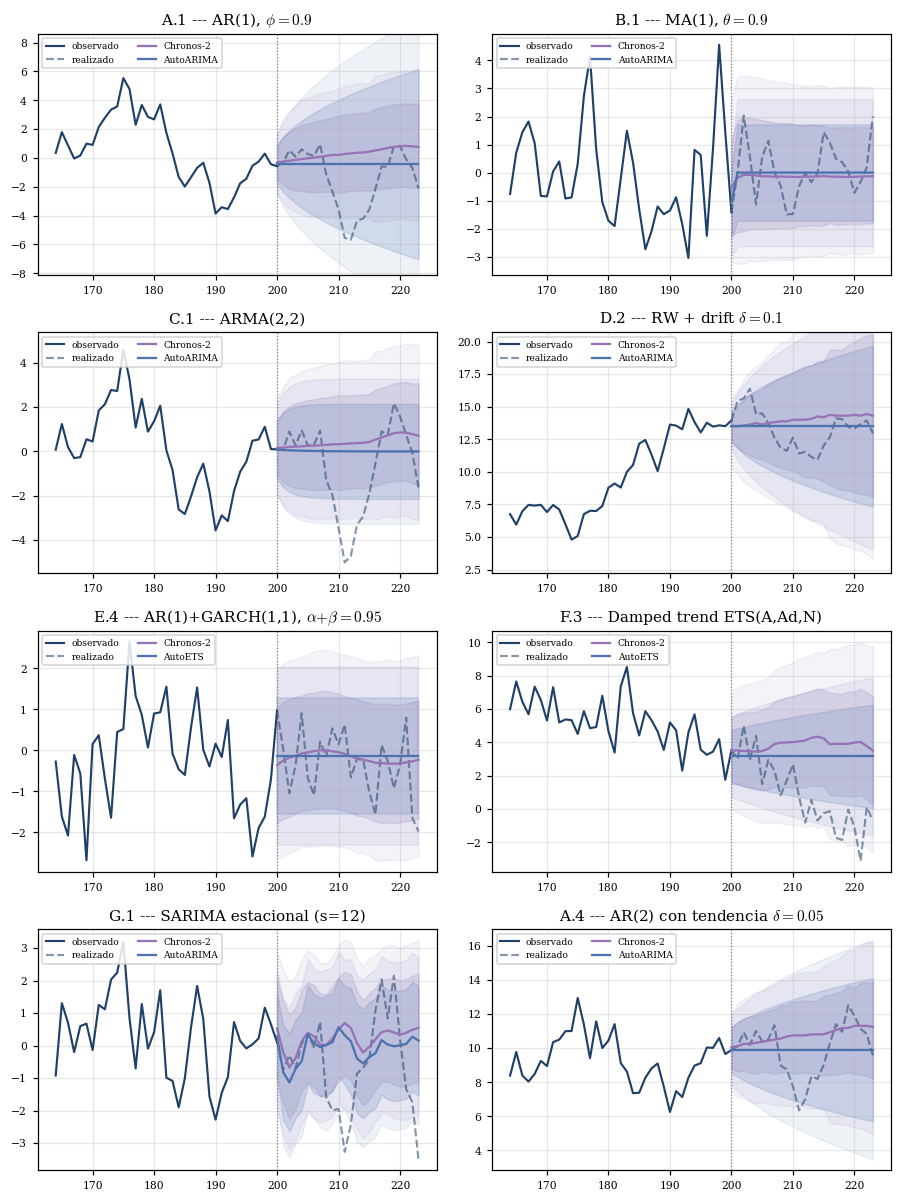

In [3]:
# (id, label, dgp factory que devuelve serie de longitud TOTAL, factory de modelo clasico)
uni_dgps = [
    ("A.1", r"AR(1), $\phi=0.9$",
        lambda: ARpDGP(phis=[0.9], sigma=1.0, seed=SEED).simulate(TOTAL),
        lambda: AutoARIMAModel(season_length=1), "AutoARIMA"),
    ("B.1", r"MA(1), $\theta=0.9$",
        lambda: MAqDGP(thetas=[0.9], sigma=1.0, seed=SEED).simulate(TOTAL),
        lambda: AutoARIMAModel(season_length=1), "AutoARIMA"),
    ("C.1", r"ARMA(2,2)",
        lambda: ARMApqDGP(phis=[0.4, 0.3], thetas=[0.3, 0.2], sigma=1.0, seed=SEED).simulate(TOTAL),
        lambda: AutoARIMAModel(season_length=1), "AutoARIMA"),
    ("D.2", r"RW + drift $\delta=0.1$",
        lambda: RandomWalk(seed=SEED).simulate(TOTAL, drift=0.1, sigma=1.0),
        lambda: AutoARIMAModel(season_length=1), "AutoARIMA"),
    ("E.4", r"AR(1)+GARCH(1,1), $\alpha{+}\beta=0.95$",
        lambda: AR1GARCH(seed=SEED).simulate(TOTAL, phi=0.3, omega=0.05, alpha=0.1, beta=0.85),
        lambda: AutoETSModel(season_length=1), "AutoETS"),
    ("F.3", r"Damped trend ETS(A,Ad,N)",
        lambda: DampedTrendDGP(seed=SEED).simulate(TOTAL, phi=0.9),
        lambda: AutoETSModel(season_length=1), "AutoETS"),
    ("G.1", r"SARIMA estacional (s=12)",
        lambda: SeasonalDGP(seed=SEED).simulate(TOTAL, phi=0.5, Phi=0.5, s=12, integrated=False),
        lambda: AutoARIMAModel(season_length=12), "AutoARIMA"),
    ("A.4", r"AR(2) con tendencia $\delta=0.05$",
        lambda: ARMApqWithTrendDGP(phis=[0.5, 0.3], thetas=[], delta=0.05, sigma=1.0, seed=SEED).simulate(TOTAL),
        lambda: AutoARIMAModel(season_length=1), "AutoARIMA"),
]

fig, axes = plt.subplots(4, 2, figsize=(8.27, 11.0))
axes_flat = axes.flatten()

for ax, (exp_id, label, dgp_fn, classic_factory, classic_name) in zip(axes_flat, uni_dgps):
    arr = np.asarray(dgp_fn(), dtype=float)
    y_full = to_series(arr)
    y_train = y_full.iloc[:T_TRAIN].values
    y_history = y_full.iloc[:T_TRAIN].values

    forecasts = {}
    try:
        forecasts["Chronos-2"] = fan_dict_uni(chronos, y_train, HORIZON)
    except Exception as e:
        print(f"[{exp_id}] Chronos fallo: {e}")

    try:
        forecasts[classic_name] = fan_dict_uni(classic_factory(), y_train, HORIZON)
    except Exception as e:
        print(f"[{exp_id}] {classic_name} fallo: {e}")

    plot_forecast_fan(
        y_full, forecasts,
        origin_idx=T_TRAIN, horizon=HORIZON,
        history_tail=HISTORY_TAIL,
        title=f"{exp_id} --- {label}",
        ax=ax, colors=MODEL_COLORS,
    )
    clip_to_history(ax, y_history)
    ax.legend(loc="upper left", fontsize=6, ncol=2, framealpha=0.85)
    ax.tick_params(labelsize=7)

fig.tight_layout(h_pad=1.0, w_pad=1.5)
out = OUTPUT_DIR / "anexo_simulaciones_univariadas.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 3 · Bloque multivariado --- `anexo_simulaciones_multivariadas.pdf`

6 DGPs bivariados (k=2) cubriendo los bloques M-A a M-F del experimento
`multivariate_v6_vertexai`. Cada DGP tiene dos sub-paneles apilados (una
variable por panel) con Chronos-2 (joint mode) y el VAR/VECM clasico
correspondiente. Para M-B.6 (cerca de raiz unitaria) se recorta el eje y al
rango +/- 4 std de la historia para evitar que la divergencia de Chronos rompa
la escala.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\entrega\tesis\output\anexo_simulaciones_multivariadas.pdf


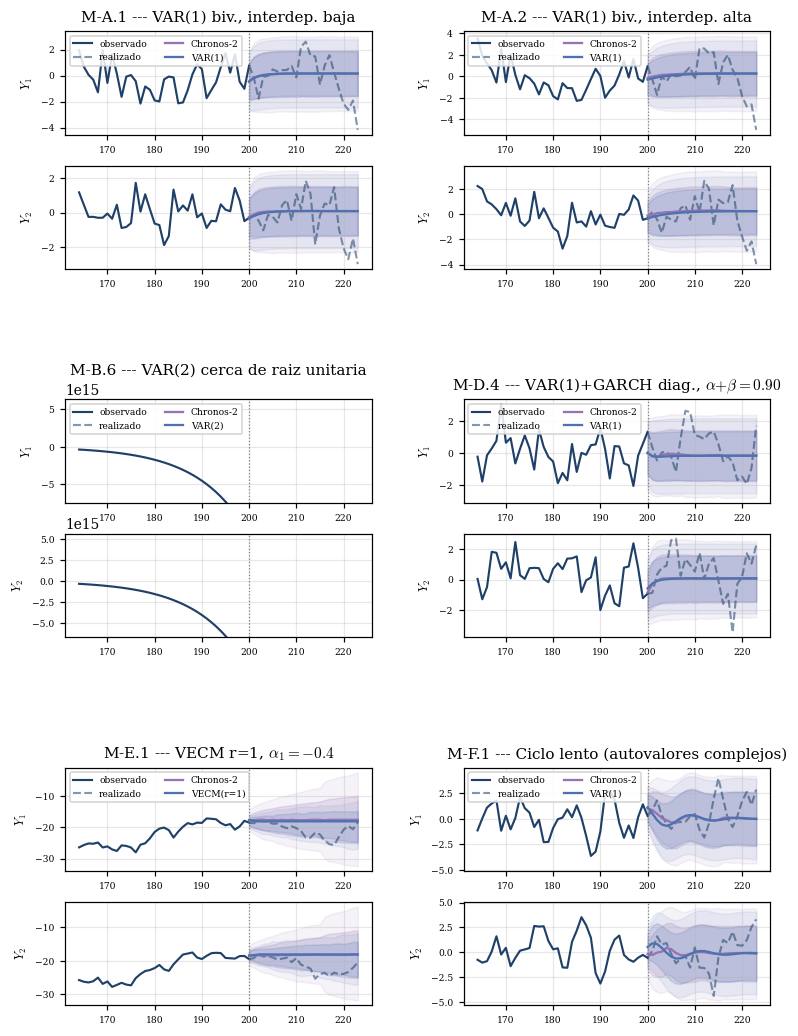

In [4]:
# (id, label, dgp factory, clasico factory, clasico name, clip_flag)
def _va(a11, a12, a21, a22, rho_sigma=0.3):
    A = np.array([[a11, a12], [a21, a22]])
    Sigma = np.array([[1.0, rho_sigma], [rho_sigma, 1.0]])
    return A, Sigma

multi_dgps = [
    ("M-A.1", r"VAR(1) biv., interdep. baja",
        lambda: VARDGP(seed=SEED, A_list=[_va(0.5, 0.1, 0.1, 0.5)[0]],
                       Sigma=_va(0.5, 0.1, 0.1, 0.5)[1]).simulate(TOTAL),
        lambda: VARModel(lags=1), "VAR(1)", False),
    ("M-A.2", r"VAR(1) biv., interdep. alta",
        lambda: VARDGP(seed=SEED, A_list=[_va(0.4, 0.4, 0.4, 0.4)[0]],
                       Sigma=_va(0.4, 0.4, 0.4, 0.4)[1]).simulate(TOTAL),
        lambda: VARModel(lags=1), "VAR(1)", False),
    ("M-B.6", r"VAR(2) cerca de raiz unitaria",
        lambda: VARDGP(seed=SEED,
                       A_list=[np.array([[0.7, 0.2], [0.15, 0.7]]),
                               np.array([[0.2, 0.05], [0.05, 0.2]])],
                       Sigma=np.eye(2)).simulate(TOTAL),
        lambda: VARModel(lags=2), "VAR(2)", True),
    ("M-D.4", r"VAR(1)+GARCH diag., $\alpha{+}\beta=0.90$",
        lambda: VARGARCHDiagonalDGP(seed=SEED,
                                    A1=np.array([[0.5, 0.1], [0.1, 0.5]]),
                                    omegas=[0.1, 0.1], alphas=[0.1, 0.1], betas=[0.8, 0.8]).simulate(TOTAL),
        lambda: VARModel(lags=1), "VAR(1)", False),
    ("M-E.1", r"VECM r=1, $\alpha_1=-0.4$",
        lambda: VECMBivariateDGP(seed=SEED, alpha=[-0.4, 0.2], beta=[1.0, -1.0],
                                 Gamma1=[[0.3, 0.0], [0.0, 0.3]],
                                 Sigma=[[1.0, 0.0], [0.0, 1.0]]).simulate(TOTAL),
        lambda: VECMModel(coint_rank=1, k_ar_diff=1), "VECM(r=1)", False),
    ("M-F.1", r"Ciclo lento (autovalores complejos)",
        lambda: VARDGP(seed=SEED,
                       A_list=[np.array([[0.7, -0.5], [0.5, 0.7]])],
                       Sigma=np.eye(2)).simulate(TOTAL),
        lambda: VARModel(lags=1), "VAR(1)", False),
]

# Layout: 3 filas de DGPs x 2 columnas de DGPs; cada DGP ocupa 2 filas internas (1 por variable)
# Total: 3*2 = 6 filas externas, cada DGP es un bloque de 2 filas x 1 col
n_dgps = len(multi_dgps)
ncols_dgp = 2
nrows_dgp = (n_dgps + ncols_dgp - 1) // ncols_dgp   # = 3

fig = plt.figure(figsize=(8.27, 11.5))
outer = GridSpec(nrows_dgp, ncols_dgp, figure=fig, hspace=0.55, wspace=0.30)

for d, (exp_id, label, dgp_fn, classic_factory, classic_name, do_clip) in enumerate(multi_dgps):
    r, c = divmod(d, ncols_dgp)
    inner = outer[r, c].subgridspec(2, 1, hspace=0.30)

    Y_arr = np.asarray(dgp_fn(), dtype=float)
    Y_full = to_frame(Y_arr, prefix="Y")
    Y_train = Y_full.iloc[:T_TRAIN].values

    # Chronos joint multivariate
    chronos_mv = ChronosMultivariateModel(chronos)
    try:
        f_chronos = fan_dict_multi(chronos_mv, Y_train, HORIZON)
    except Exception as e:
        print(f"[{exp_id}] Chronos multi fallo: {e}")
        f_chronos = None

    # Clasico
    try:
        f_classic = fan_dict_multi(classic_factory(), Y_train, HORIZON)
    except Exception as e:
        print(f"[{exp_id}] {classic_name} fallo: {e}")
        f_classic = None

    for j in range(2):
        ax = fig.add_subplot(inner[j])
        forecasts = {}
        if f_chronos is not None:
            forecasts["Chronos-2"] = f_chronos
        if f_classic is not None:
            forecasts[classic_name] = f_classic

        plot_forecast_fan(
            Y_full.iloc[:, j], forecasts,
            origin_idx=T_TRAIN, horizon=HORIZON,
            history_tail=HISTORY_TAIL,
            title=(f"{exp_id} --- {label}" if j == 0 else ""),
            ax=ax, variable_idx=j, colors=MODEL_COLORS,
        )
        if do_clip:
            clip_to_history(ax, Y_full.iloc[:T_TRAIN, j].values)
        ax.set_ylabel(f"$Y_{{{j+1}}}$", fontsize=8)
        ax.tick_params(labelsize=6)
        if j == 0:
            ax.legend(loc="upper left", fontsize=6, ncol=2, framealpha=0.85)
        else:
            ax.get_legend().remove() if ax.get_legend() else None

out = OUTPUT_DIR / "anexo_simulaciones_multivariadas.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 4 · Bloque covariadas --- `anexo_simulaciones_covariadas.pdf`

6 DGPs con un target univariado y una covariable exogena, cubriendo los
bloques C-A a C-J del experimento `covariate_v6_vertexai`. Cada DGP tiene
**dos sub-paneles apilados**: arriba el **target** con fan-plot completo
(Chronos-2 con covariables vs SARIMAX con xreg); abajo la **exogena** mostrada
solo como historia (linea gris), para ilustrar como participa la X.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\entrega\tesis\output\anexo_simulaciones_covariadas.pdf


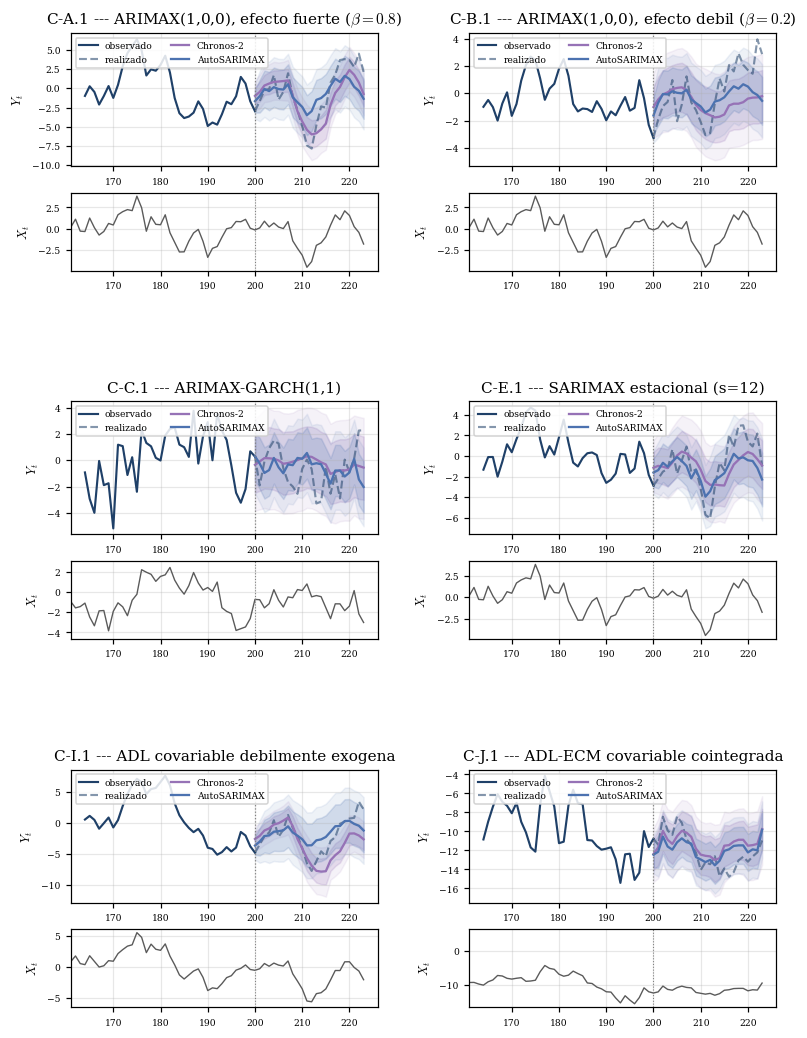

In [5]:
# (id, label, dgp_fn que devuelve dict {y, X}, clasico factory, clasico name)
cov_dgps = [
    ("C-A.1", r"ARIMAX(1,0,0), efecto fuerte ($\beta=0.8$)",
        lambda: ARIMAX_DGP(seed=SEED).simulate(TOTAL, phi=0.6, beta=0.8, rho_x=0.7),
        lambda: AutoSARIMAXModel(season_length=1)),
    ("C-B.1", r"ARIMAX(1,0,0), efecto debil ($\beta=0.2$)",
        lambda: ARIMAX_DGP(seed=SEED).simulate(TOTAL, phi=0.6, beta=0.2, rho_x=0.7),
        lambda: AutoSARIMAXModel(season_length=1)),
    ("C-C.1", r"ARIMAX-GARCH(1,1)",
        lambda: ARIMAX_GARCH_DGP(seed=SEED).simulate(TOTAL, phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.1),
        lambda: AutoSARIMAXModel(season_length=1)),
    ("C-E.1", r"SARIMAX estacional (s=12)",
        lambda: SARIMAX_SEASONAL_DGP(seed=SEED).simulate(TOTAL, s=12, phi=0.5, Phi=0.5, beta=0.5),
        lambda: AutoSARIMAXModel(season_length=12)),
    ("C-I.1", r"ADL covariable debilmente exogena",
        lambda: ARIMAX_DGP(seed=SEED).simulate(TOTAL, phi=0.7, beta=0.5, rho_x=0.9),
        lambda: AutoSARIMAXModel(season_length=1)),
    ("C-J.1", r"ADL-ECM covariable cointegrada",
        lambda: ADL_ECM_DGP(seed=SEED).simulate(TOTAL, alpha_ecm=-0.3),
        lambda: AutoSARIMAXModel(season_length=1)),
]

n_dgps = len(cov_dgps)
ncols_dgp = 2
nrows_dgp = (n_dgps + ncols_dgp - 1) // ncols_dgp

fig = plt.figure(figsize=(8.27, 11.5))
outer = GridSpec(nrows_dgp, ncols_dgp, figure=fig, hspace=0.55, wspace=0.30)

for d, (exp_id, label, dgp_fn, classic_factory) in enumerate(cov_dgps):
    r, c = divmod(d, ncols_dgp)
    inner = outer[r, c].subgridspec(2, 1, height_ratios=[1.7, 1.0], hspace=0.25)

    data = dgp_fn()
    y_arr = np.asarray(data["y"], dtype=float)
    X_arr = np.asarray(data["X"], dtype=float)  # (T, p)

    y_full = to_series(y_arr, name="Y")
    y_train = y_full.iloc[:T_TRAIN].values
    X_train = X_arr[:T_TRAIN]
    X_future = X_arr[T_TRAIN:T_TRAIN + HORIZON]
    p_x = X_arr.shape[1]

    # Chronos con covariables (univariado target)
    chronos_cov = ChronosCovariateModel(chronos, n_covariates=p_x,
                                        cov_names=[f"x{i}" for i in range(p_x)])
    forecasts = {}
    try:
        forecasts["Chronos-2"] = fan_dict_cov(chronos_cov, y_train, X_train, X_future, HORIZON)
    except Exception as e:
        print(f"[{exp_id}] Chronos cov fallo: {e}")

    try:
        forecasts["AutoSARIMAX"] = fan_dict_cov(classic_factory(), y_train, X_train, X_future, HORIZON)
    except Exception as e:
        print(f"[{exp_id}] AutoSARIMAX fallo: {e}")

    # Sub-panel 1: target con fan-plot
    ax_y = fig.add_subplot(inner[0])
    plot_forecast_fan(
        y_full, forecasts,
        origin_idx=T_TRAIN, horizon=HORIZON,
        history_tail=HISTORY_TAIL,
        title=f"{exp_id} --- {label}",
        ax=ax_y, colors=MODEL_COLORS,
    )
    ax_y.set_ylabel("$Y_t$", fontsize=8)
    ax_y.tick_params(labelsize=6)
    ax_y.legend(loc="upper left", fontsize=6, ncol=2, framealpha=0.85)

    # Sub-panel 2: exogena (solo historia)
    ax_x = fig.add_subplot(inner[1])
    x_series = pd.Series(X_arr[:, 0], index=pd.RangeIndex(len(X_arr)), name="X")
    plot_history_only(ax_x, x_series, color="#5a5a5a", lw=0.9)
    ax_x.set_ylabel("$X_t$", fontsize=8)
    ax_x.tick_params(labelsize=6)
    ax_x.set_xlim(*ax_y.get_xlim())

out = OUTPUT_DIR / "anexo_simulaciones_covariadas.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 5 · Verificacion

In [6]:
for fname in [
    "anexo_simulaciones_univariadas.pdf",
    "anexo_simulaciones_multivariadas.pdf",
    "anexo_simulaciones_covariadas.pdf",
]:
    p = OUTPUT_DIR / fname
    status = "OK" if p.exists() else "MISSING"
    size_kb = p.stat().st_size / 1024 if p.exists() else 0
    print(f"  [{status}] {fname:42s} {size_kb:8.1f} KB")

  [OK] anexo_simulaciones_univariadas.pdf             45.7 KB
  [OK] anexo_simulaciones_multivariadas.pdf           54.2 KB
  [OK] anexo_simulaciones_covariadas.pdf              49.9 KB
